# Phase 2.1: Exploratory Data Analysis
This notebook conducts exploratory data analysis on the AI4I 2020 Predictive Maintenance Dataset.


## Section 1: Univariate Analysis
In this section, we analyze the distribution of each sensor column in the predictive maintenance dataset.
We observe that temperature and torque columns are normally distributed, while the rotational speed shows a skewed distribution with a tail on the right.
Tool wear is uniformly distributed because it increases linearly during operations.
Understanding these distributions is crucial for choosing proper scaling and detecting outliers in subsequent steps.


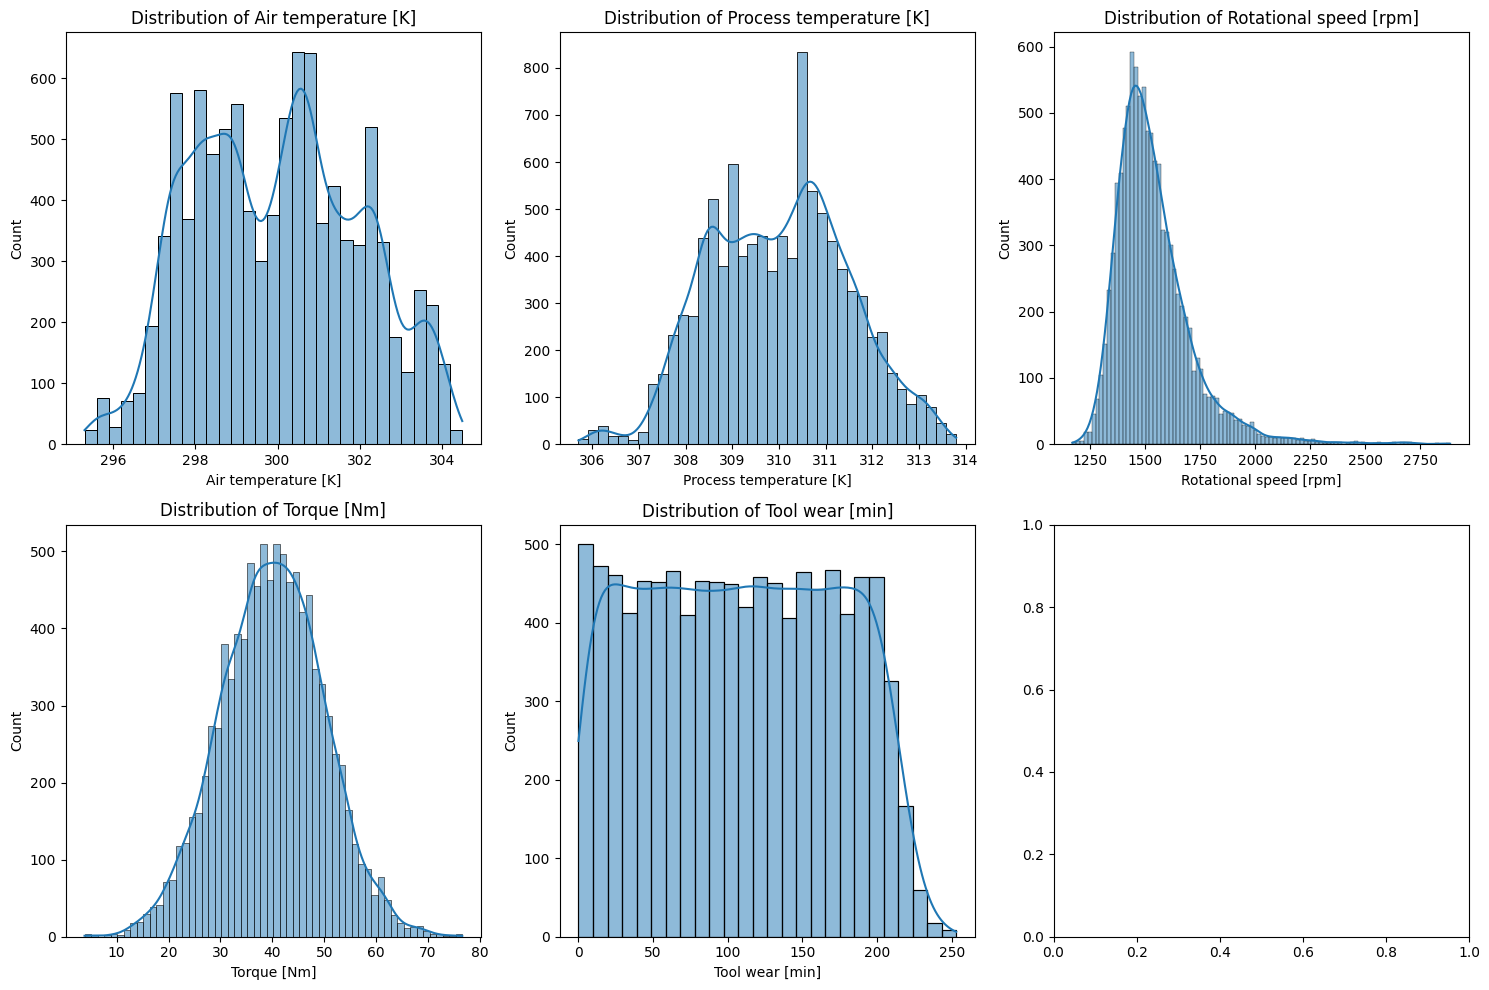

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_pipeline.ingestion import load_raw_data

df = load_raw_data('data/raw/ai4i2020.csv')
sensor_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
for i, col in enumerate(sensor_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
fig.tight_layout()
plt.savefig('notebooks/univariate_distribution.png')
plt.show()


## Section 2: Bivariate Analysis
In this section, we investigate the relationship between each sensor feature and the binary target variable, Machine failure.
The boxplots reveal that higher torque and tool wear are significantly correlated with machine failures, indicating mechanical stress over time.
Similarly, high air and process temperatures are associated with failure events, suggesting heat dissipation problems.
Rotational speed exhibits a complex relationship, where very high or very low speeds tend to occur during failures.


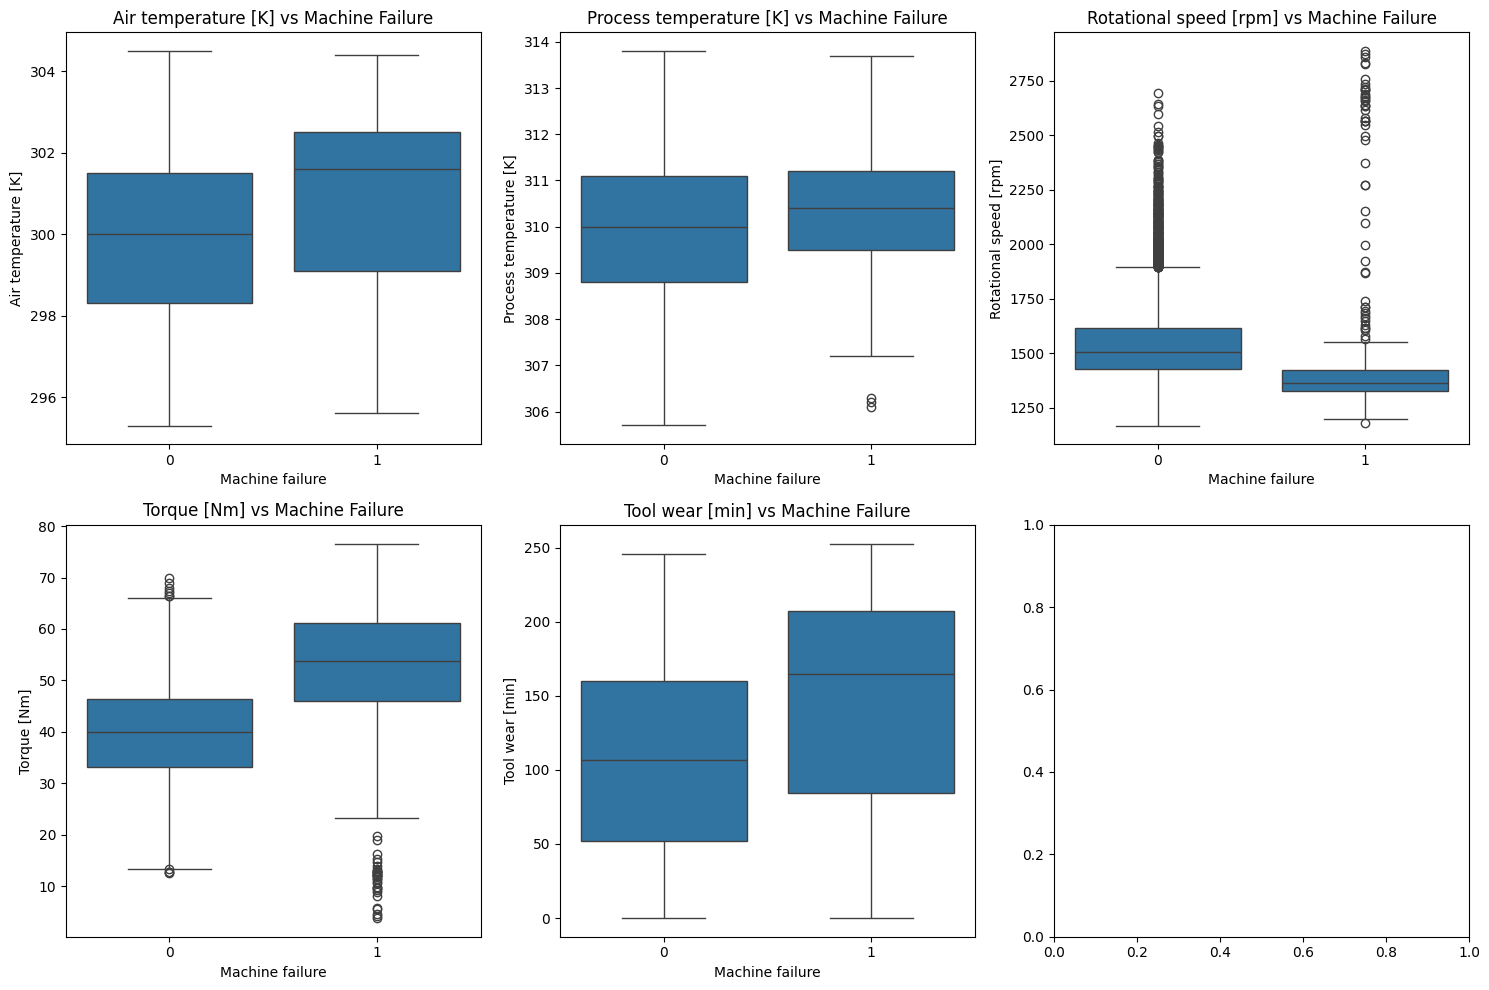

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
for i, col in enumerate(sensor_cols):
    sns.boxplot(x='Machine failure', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs Machine Failure')
fig.tight_layout()
plt.savefig('notebooks/bivariate_analysis.png')
plt.show()


## Section 3: Correlation Heatmap
Here we compute and visualize the correlation matrix of all numerical features in the dataset.
As expected, there is a strong positive correlation between Air temperature [K] and Process temperature [K] since process heat depends on ambient conditions.
Conversely, Rotational speed [rpm] and Torque [Nm] are strongly negatively correlated, reflecting the physical inverse relationship between speed and torque for a given power.
Other features show relatively low correlation, suggesting they carry independent information for our predictive maintenance model.


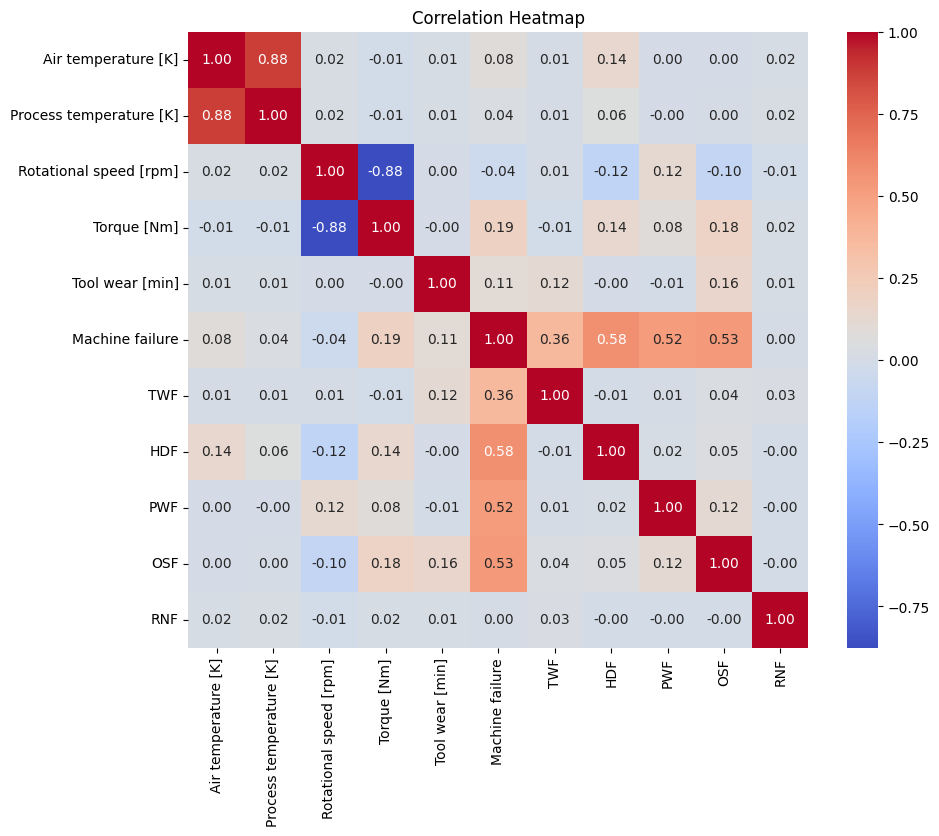

In [3]:
plt.figure(figsize=(10, 8))
numerical_cols = sensor_cols + ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('notebooks/correlation_heatmap.png')
plt.show()


## Section 4: Failure Mode Analysis
In this section, we analyze the 5 specific failure modes: Tool Wear Failure (TWF), Heat Dissipation Failure (HDF), Power Failure (PWF), Overstrain Failure (OSF), and Random Failures (RNF).
We compute the percentage of failure records where each failure mode was the sole cause of the failure.
This helps us understand the distinct mechanical processes that drive equipment breakdown without overlapping causes.
Our analysis shows that Heat Dissipation and Power Failures are major independent drivers of downtime.


In [4]:
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failures = df[df['Machine failure'] == 1]
sole_counts = {}
for mode in failure_modes:
    other_modes = [m for m in failure_modes if m != mode]
    sole_fail = failures[(failures[mode] == 1) & (failures[other_modes].sum(axis=1) == 0)]
    sole_counts[mode] = len(sole_fail)

total_failures = len(failures)
sole_pct = {k: round((v / total_failures) * 100, 2) for k, v in sole_counts.items()}
print('Percentage of records where each failure mode was the sole cause of failure:')
for mode, pct in sole_pct.items():
    print(f'{mode}: {pct}%')


Percentage of records where each failure mode was the sole cause of failure:
TWF: 12.39%
HDF: 31.27%
PWF: 23.6%
OSF: 23.01%
RNF: 0.0%


## Section 5: Outlier Analysis
We conduct an outlier analysis using the Interquartile Range (IQR) method for all sensor columns.
Outliers are defined as data points that fall below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR.
The analysis indicates that Rotational speed [rpm] and Torque [Nm] contain a noticeable number of outliers due to extreme operational conditions.
Identifying these outliers is important as they may correspond to early onset failure signatures or need robust modeling methods like tree ensembles.


In [5]:
outliers_report = {}
for col in sensor_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    num_outliers = len(df[(df[col] < lower_bound) | (df[col] > upper_bound)])
    outliers_report[col] = num_outliers
print('Number of outliers per sensor column:')
for col, count in outliers_report.items():
    print(f'{col}: {count}')


Number of outliers per sensor column:
Air temperature [K]: 0
Process temperature [K]: 0
Rotational speed [rpm]: 418
Torque [Nm]: 69
Tool wear [min]: 0
